In [185]:
# Data Manipulation Imports
import numpy as np
import pandas as pd
import xarray as xr
import scipy

# Plotting Imports
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

from datetime import datetime, date, time, timedelta
import matplotlib.dates as mdates
import zack_functions as zf
import cftime

In [135]:
date1

Timestamp('2024-06-01 00:00:00')

In [2]:
# Path to Crocolake
parquet_dir = '/home/jovyan/shared/go-bgc-2026/data/CrocoLake/BGC_CROCOLAKE/'

# path to heatwave csv
csv_path = '../../MHW_list.csv'

dfhw = pd.read_csv(csv_path)
dfhw.set_index('name',inplace=True)
date_cols = ['date_start','date_end']
dfhw[date_cols] = dfhw[date_cols].apply(pd.to_datetime)

# Choose a HW
hw = "NA 2023"

# Boundaries
lat0 = dfhw.loc[hw,'lat0'] 
lat1 = dfhw.loc[hw,'lat1'] 
lon0 = dfhw.loc[hw,'lon0'] 
lon1 = dfhw.loc[hw,'lon1'] 

date0 = dfhw.loc[hw,'date_start']
date1 = dfhw.loc[hw,'date_end']

datetime.datetime(2022, 1, 1, 0, 0)

In [147]:
%%time

# Parameters
columns = ('PRES','TEMP','PSAL','DOXY','CHLA','BBP700','LATITUDE','LONGITUDE','JULD','CYCLE_NUMBER','DB_NAME','PLATFORM_NUMBER')


# without DB_NAME you also would get any Spray glider or shipboard GLODAP data too
filters = [
    ("LATITUDE",">",35), ("LATITUDE","<",lat1),
    ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
    ("JULD",">",datetime(2021, 1, 1)), ("JULD","<",datetime(2025, 1, 1)),
    ("DB_NAME","=","ARGO") 
]

df = pd.read_parquet(parquet_dir,columns=columns,filters=filters)
df = df.dropna(subset=['DOXY','CHLA','BBP700','PSAL','TEMP'])
df

CPU times: user 18.6 s, sys: 1.32 s, total: 19.9 s
Wall time: 6.51 s


,PRES,TEMP,PSAL,DOXY,CHLA,BBP700,LATITUDE,LONGITUDE,JULD,CYCLE_NUMBER,DB_NAME,PLATFORM_NUMBER
0,2.54,11.013,35.179001,273.9776,0.798698,0.001713,59.6959,-23.2117,2024-09-24 22:08:05.002372096,7,ARGO,3902261
1,4.34,11.012,35.179001,274.063049,0.80132,0.001679,59.6959,-23.2117,2024-09-24 22:08:05.002372096,7,ARGO,3902261
2,6.34,11.013,35.179001,273.971893,0.790834,0.001683,59.6959,-23.2117,2024-09-24 22:08:05.002372096,7,ARGO,3902261
3,8.34,11.014,35.179001,273.997406,0.78996,0.001664,59.6959,-23.2117,2024-09-24 22:08:05.002372096,7,ARGO,3902261
4,10.440001,11.014,35.179001,273.942505,0.780348,0.001916,59.6959,-23.2117,2024-09-24 22:08:05.002372096,7,ARGO,3902261
...,...,...,...,...,...,...,...,...,...,...,...,...
13061248,746.942017,3.821316,34.869953,273.33548,0.015366,0.0003,52.17162,-40.32735,2022-09-14 12:19:06,121,ARGO,7900589
13061250,796.453979,3.81169,34.876293,272.646362,0.015427,0.000586,52.17162,-40.32735,2022-09-14 12:19:06,121,ARGO,7900589
13061252,846.247986,3.797406,34.878487,273.14743,0.02145,0.000273,52.17162,-40.32735,2022-09-14 12:19:06,121,ARGO,7900589
13061254,896.568054,3.642829,34.864014,277.664398,0.015331,0.000273,52.17162,-40.32735,2022-09-14 12:19:06,121,ARGO,7900589


In [148]:
df = df[df.PRES <= 300]
df = df[df.CHLA >= 0]

In [149]:
var_names = ['PRES','TEMP','PSAL','DOXY','CHLA','BBP700','LATITUDE','LONGITUDE','JULD']
PRES, TEMP, PSAL, DOXY, CHLA, BBP700, LATITUDE, LONGITUDE, JULD = var_names

In [150]:
data_da = df.set_index(JULD).resample('W').mean(numeric_only=True).dropna(how='all').reset_index()
peaks, _ = scipy.signal.find_peaks(data_da[CHLA], distance = 300/7)
full_bloom_slices = []
bloom_slices = []
for peak in peaks:
    bloom_slice = data_da[data_da[JULD].between(data_da[JULD].iloc[peak] - pd.Timedelta(weeks=4*6), data_da[JULD].iloc[peak] + pd.Timedelta(weeks=4*6))]
    bloom_slices.append(bloom_slice)
    full_bloom_slices.append(df[df[JULD].between(data_da[JULD].iloc[peak] - pd.Timedelta(weeks=4*6), data_da[JULD].iloc[peak] + pd.Timedelta(weeks=4*6))])
    

In [163]:
p_df

,level_0,index,YEAR_CHLA,BLOOM_MAXIMUM_CHLA,BLOOM_PEAKS_VALUES_CHLA,BLOOM_PEAKS_JULD_CHLA,BLOOM_SLICE_CHLA,BLOOM_INITIATION_TS_CHLA,BLOOM_TERMINATION_TS_CHLA,BLOOM_DURATION_TS_CHLA,...,BLOOM_TERMINATION_RC_CHLA,BLOOM_DURATION_RC_CHLA,BLOOM_INITIATION_RC_DATE_CHLA,BLOOM_TERMINATION_RC_DATE_CHLA,INTEGRATED_BLOOM_TS_CHLA,INTEGRATED_BLOOM_CS_CHLA,INTEGRATED_BLOOM_RC_CHLA,MEAN_BLOOM_TS_CHLA,MEAN_BLOOM_CS_CHLA,MEAN_BLOOM_RC_CHLA
0,0,0.0,2021,0.525519,[0.5255188941955566],[2021-04-04 00:00:00],"[[JULD, PRES, TEMP, PSAL, DOXY, CHLA, BBP700, ...",0.525519,0.201575,14,...,0.384146,21,2021-04-04,2021-04-25,5.089659,None,7.139684,0.363547,None,0.370413
1,1,0.0,2022,0.282758,"[0.28275778889656067, 0.2338062822818756]","[2022-05-22 00:00:00, 2022-06-26 00:00:00]","[[JULD, PRES, TEMP, PSAL, DOXY, CHLA, BBP700, ...",0.081059,None,None,...,0.233806,175,2022-01-02,2022-06-26,None,None,25.639055,None,None,0.146929
2,0,NaN,2023,0.345539,[0.34553948044776917],[2023-05-28 00:00:00],"[[JULD, PRES, TEMP, PSAL, DOXY, CHLA, BBP700, ...",0.085767,None,None,...,0.230576,189,2022-12-18,2023-06-25,None,None,26.899873,None,None,0.142922


In [167]:
i = 0
for bloom_slice in bloom_slices:
    p_df1 = zf.find_bloom_phenological_indices(bloom_slices[i], var_names, 1)
    if i == 0:
        p_df = zf.find_bloom_phenological_indices(bloom_slices[i], var_names, 1)
    else:
        p_df = pd.concat([p_df, p_df1])
    i += 1
p_df.reset_index()

,index,YEAR_CHLA,BLOOM_MAXIMUM_CHLA,BLOOM_PEAKS_VALUES_CHLA,BLOOM_PEAKS_JULD_CHLA,BLOOM_SLICE_CHLA,BLOOM_INITIATION_TS_CHLA,BLOOM_TERMINATION_TS_CHLA,BLOOM_DURATION_TS_CHLA,BLOOM_INITIATION_TS_DATE_CHLA,...,BLOOM_TERMINATION_RC_CHLA,BLOOM_DURATION_RC_CHLA,BLOOM_INITIATION_RC_DATE_CHLA,BLOOM_TERMINATION_RC_DATE_CHLA,INTEGRATED_BLOOM_TS_CHLA,INTEGRATED_BLOOM_CS_CHLA,INTEGRATED_BLOOM_RC_CHLA,MEAN_BLOOM_TS_CHLA,MEAN_BLOOM_CS_CHLA,MEAN_BLOOM_RC_CHLA
0,0,2021,0.525519,[0.5255188941955566],[2021-04-04 00:00:00],"[[JULD, PRES, TEMP, PSAL, DOXY, CHLA, BBP700, ...",0.525519,0.201575,14,2021-04-04,...,0.384146,21,2021-04-04,2021-04-25,5.089659,None,7.139684,0.363547,None,0.370413
1,0,2022,0.282758,"[0.28275778889656067, 0.2338062822818756]","[2022-05-22 00:00:00, 2022-06-26 00:00:00]","[[JULD, PRES, TEMP, PSAL, DOXY, CHLA, BBP700, ...",0.081059,None,None,2022-01-02,...,0.233806,175,2022-01-02,2022-06-26,None,None,25.639055,None,None,0.146929
2,0,2023,0.345539,[0.34553948044776917],[2023-05-28 00:00:00],"[[JULD, PRES, TEMP, PSAL, DOXY, CHLA, BBP700, ...",0.085767,None,None,2023-01-29,...,0.230576,189,2022-12-18,2023-06-25,None,None,26.899873,None,None,0.142922
3,0,2024,0.262772,"[0.21211788058280945, 0.26277169585227966]","[2024-04-07 00:00:00, 2024-05-19 00:00:00]","[[JULD, PRES, TEMP, PSAL, DOXY, CHLA, BBP700, ...",0.097292,None,None,2024-01-14,...,0.152140,175,2023-12-17,2024-06-09,None,None,25.195566,None,None,0.143571


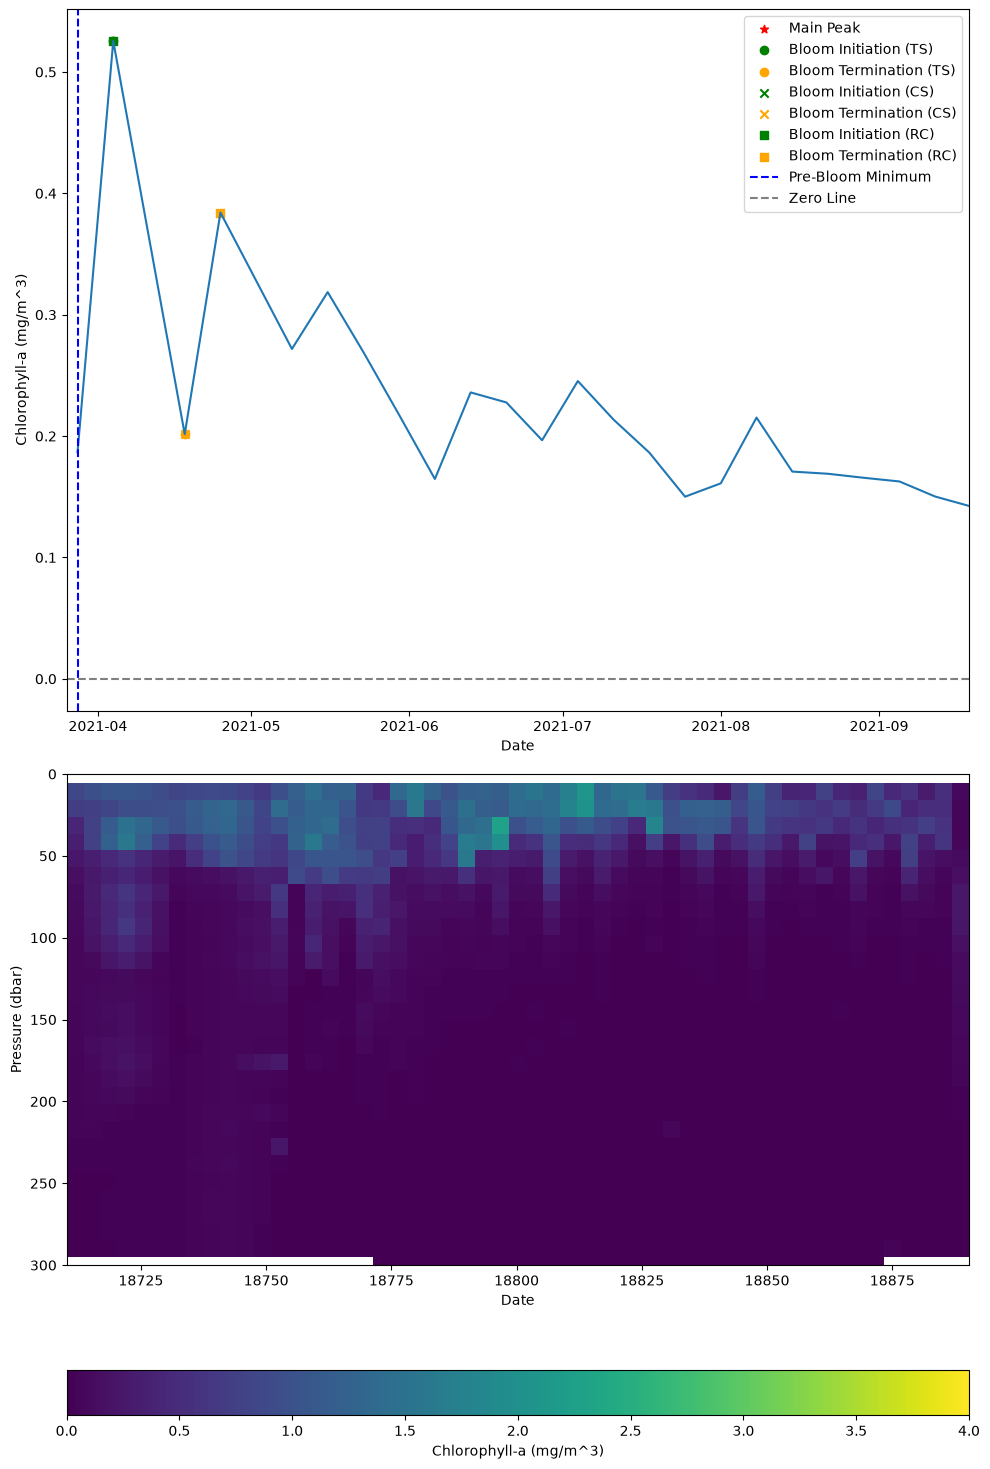

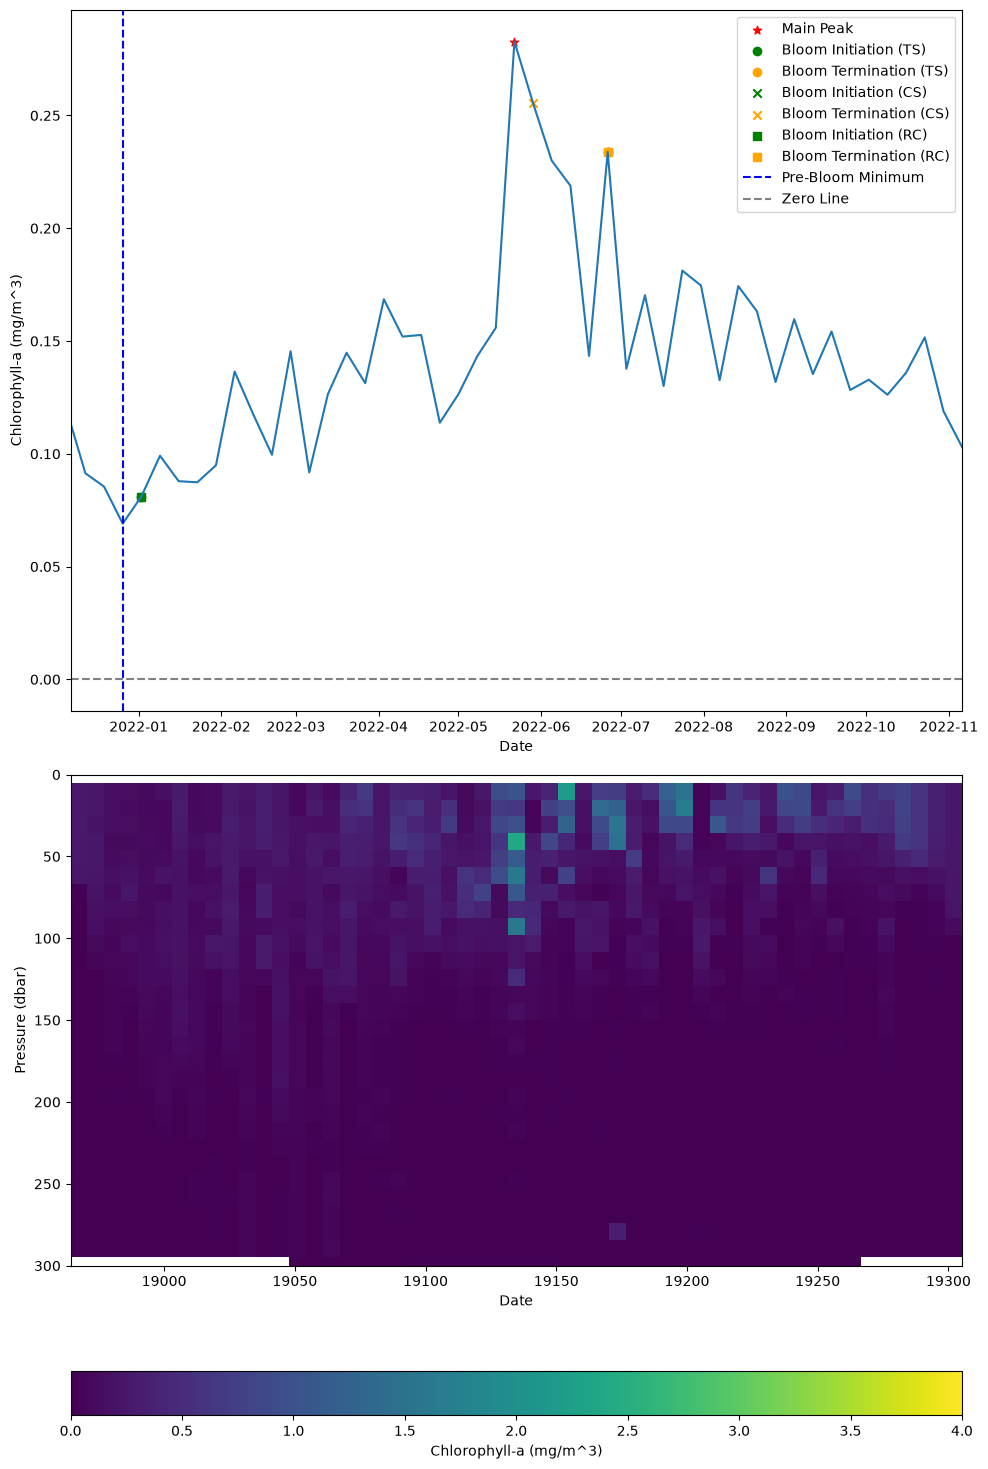

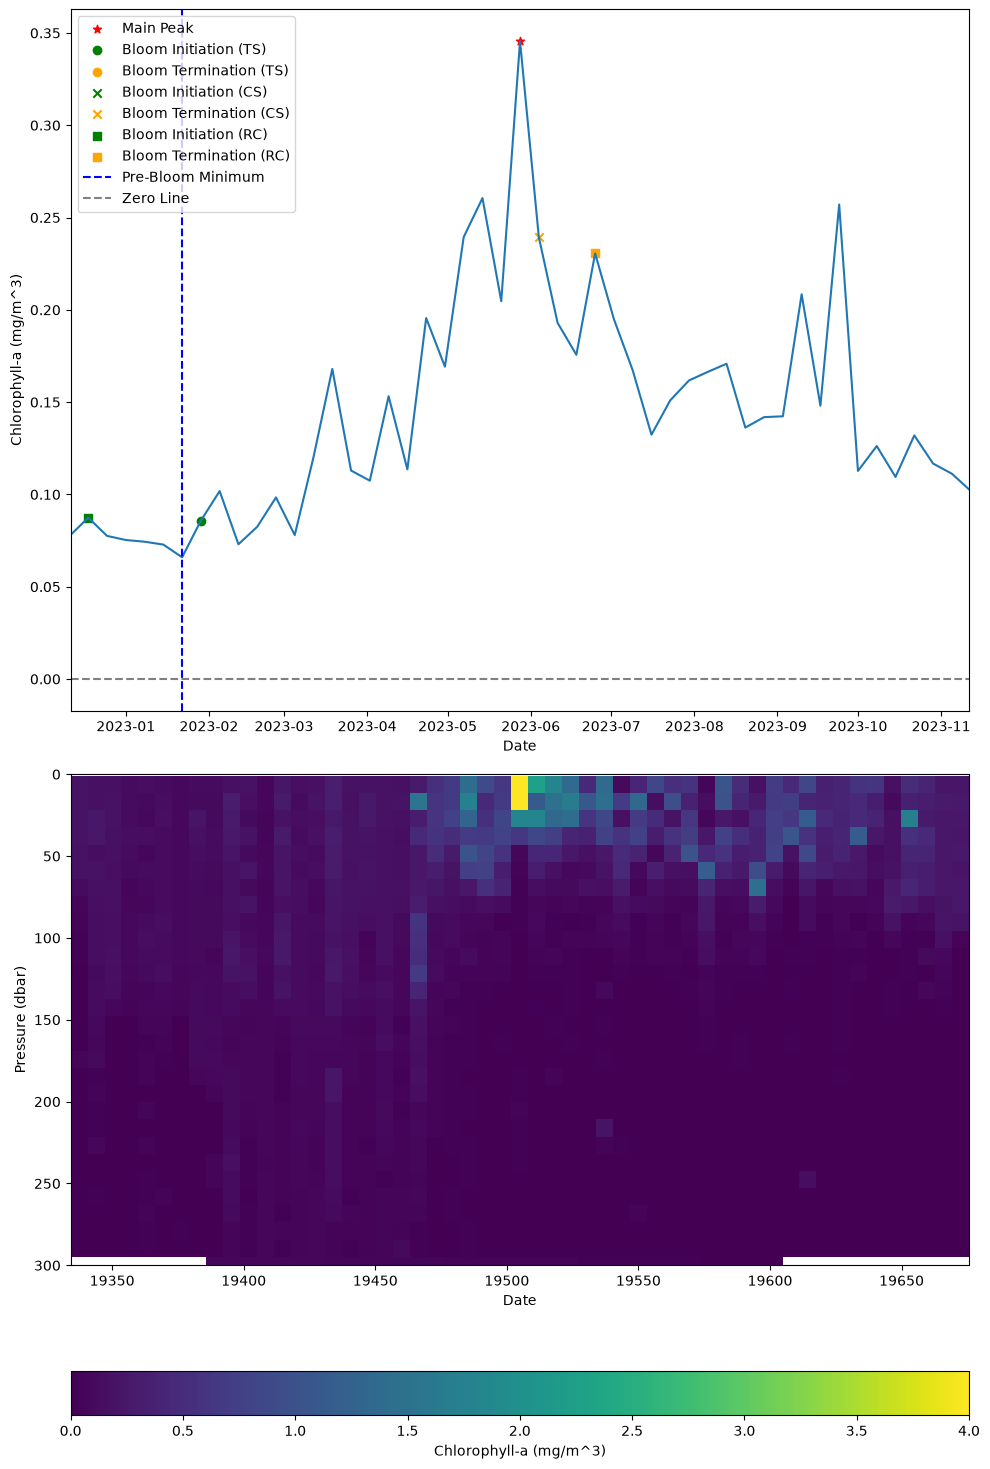

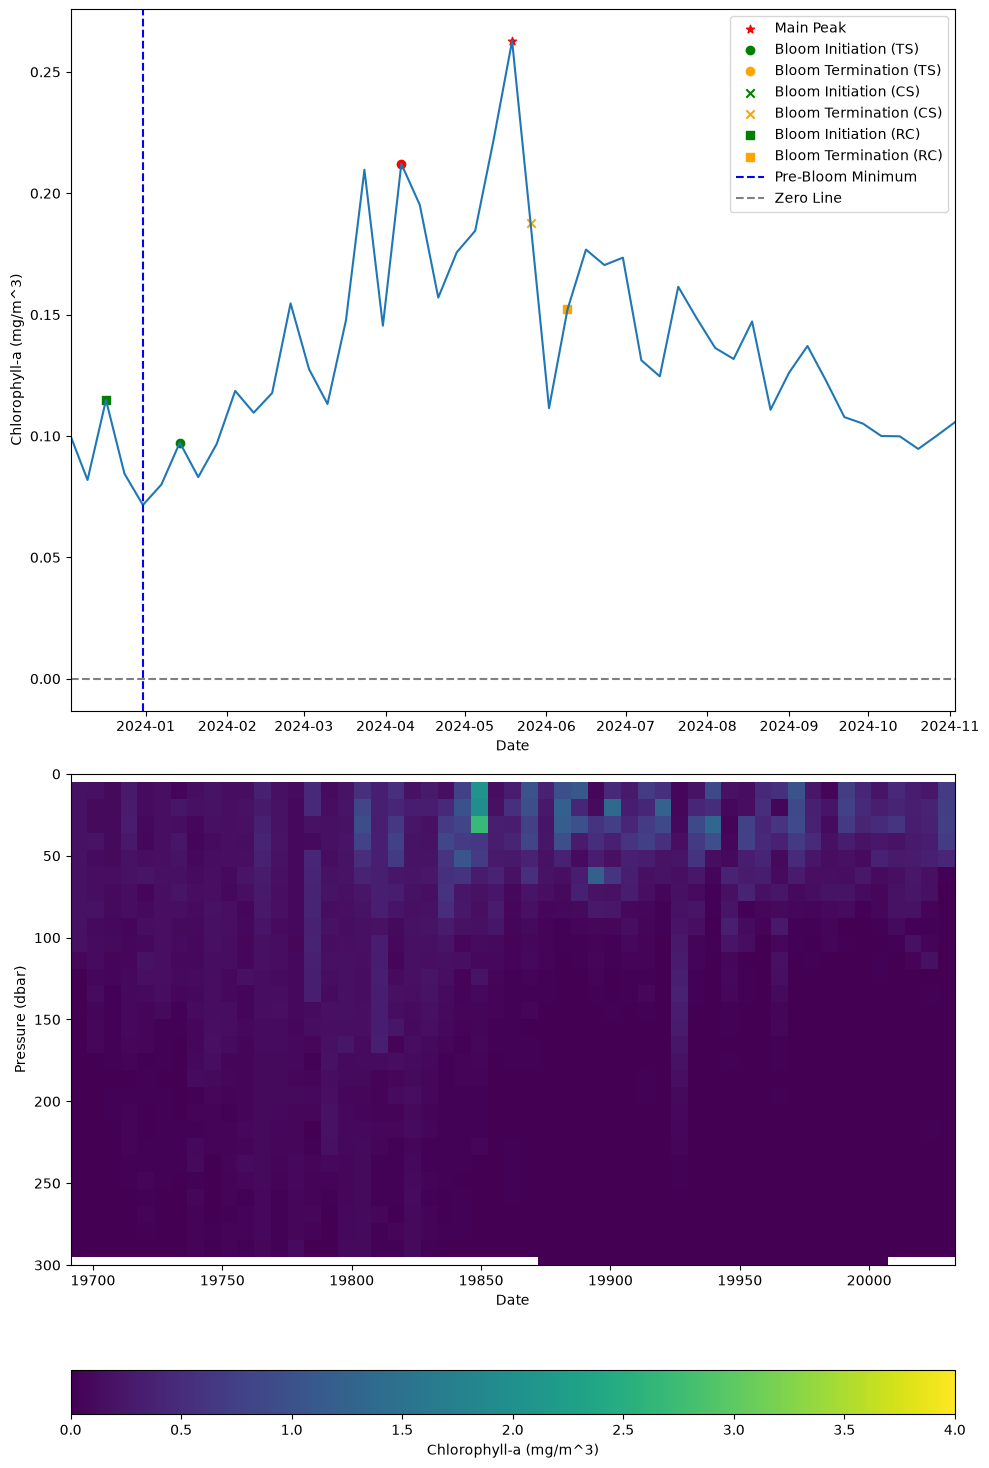

In [180]:
i = 0
fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 15))
for bloom_slice in bloom_slices:
    full_slice = full_bloom_slices[i].dropna(subset=[PRES])
    full_slice = full_slice.dropna(subset=[CHLA])
    x = mdates.date2num(full_slice["JULD"].to_numpy())
    y = full_slice[PRES].values.to_numpy()
    z = full_slice[CHLA].values.to_numpy()
    
    xi = np.linspace(x.min(), x.max(), 53)
    yi = np.linspace(y.min(), y.max(), 30)
    X, Y = np.meshgrid(xi, yi)
    Z = scipy.interpolate.griddata((x, y), z, (X, Y), method='linear')

    bloom_max = bloom_slice[CHLA].idxmax()
    pre_slice = bloom_slice.loc[:bloom_max]
    bloom_min = pre_slice[CHLA].idxmin()
    ax1.plot(bloom_slice[JULD], bloom_slice[CHLA])
    peaks, _ = scipy.signal.find_peaks(bloom_slice[CHLA], height=p_df.BLOOM_MAXIMUM_CHLA.to_list()[i] * 0.75, distance = 3)

    for peak in peaks:
        if bloom_slice[CHLA].iloc[peak] == p_df.BLOOM_MAXIMUM_CHLA.to_list()[i]:
            ax1.scatter(bloom_slice[JULD].iloc[peak], bloom_slice[CHLA].iloc[peak], color='red', marker='*', label='Main Peak')
        else:
            ax1.scatter(bloom_slice[JULD].iloc[peak], bloom_slice[CHLA].iloc[peak], color='red', marker='o')
    # for valley in valleys:
    try:
        ax1.scatter(p_df.BLOOM_INITIATION_TS_DATE_CHLA.to_list()[i], p_df.BLOOM_INITIATION_TS_CHLA.to_list()[i], color='green', marker='o', label='Bloom Initiation (TS)')
    except TypeError:
        pass
    try:
        ax1.scatter(p_df.BLOOM_TERMINATION_TS_DATE_CHLA.to_list()[i], p_df.BLOOM_TERMINATION_TS_CHLA.to_list()[i], color='orange', marker='o', label='Bloom Termination (TS)')
    except TypeError:
        pass
    try:
        ax1.scatter(p_df.BLOOM_INITIATION_CS_DATE_CHLA.to_list()[i], p_df.BLOOM_INITIATION_CS_CHLA.to_list()[i], color='green', marker='x', label='Bloom Initiation (CS)')
    except TypeError:
        pass
    try:
        ax1.scatter(p_df.BLOOM_TERMINATION_CS_DATE_CHLA.to_list()[i], p_df.BLOOM_TERMINATION_CS_CHLA.to_list()[i], color='orange', marker='x', label='Bloom Termination (CS)')
    except TypeError:
        pass
    try:
        ax1.scatter(p_df.BLOOM_INITIATION_RC_DATE_CHLA.to_list()[i], p_df.BLOOM_INITIATION_RC_CHLA.to_list()[i], color='green', marker='s', label='Bloom Initiation (RC)')
    except TypeError:
        pass
    try:
        ax1.scatter(p_df.BLOOM_TERMINATION_RC_DATE_CHLA.to_list()[i], p_df.BLOOM_TERMINATION_RC_CHLA.to_list()[i], color='orange', marker='s', label='Bloom Termination (RC)')
    except TypeError:
        pass
    ax1.axvline(bloom_slice[JULD].loc[bloom_min], color='blue', linestyle='--', label='Pre-Bloom Minimum')
    ax1.axhline(0, color='gray', linestyle='--', label='Zero Line')
    ax1.set_xlabel("Date")
    ax1.set_xlim(full_slice[JULD].min(), full_slice[JULD].max())
    ax1.set_ylabel("Chlorophyll-a (mg/m^3)")
    ax1.legend()
    # ax1.set_title(f"Region {region} {round_to_year(bloom_slice['JULD'].loc[bloom_max]).year} - Bloom Phenology")
    # plt.tight_layout()
    # plt.savefig(f"region_{region}_{round_to_year(bloom_slice['JULD'].loc[bloom_max]).year}.png")
    # plt.show()
    # time_bins = pd.date_range("2023-01-01", periods=53, freq="w")
    # test = []
    # for j in range(len(full_bloom_slices[i][JULD])):
    #     test.append(full_bloom_slices[i][JULD].to_list()[j].to_datetime64())
    # grid_x, grid_y = np.meshgrid(
    # np.linspace(0, 300, 10),
    # time_bins
    # )
    pc = ax2.pcolormesh(X, Y, Z, shading='auto', cmap='viridis', vmin=0, vmax = 4)

    # pc = ax2.scatter(full_bloom_slices[i][JULD], full_bloom_slices[i][PRES], c=full_bloom_slices[i][CHLA], s=2, vmin=0, vmax=4)
    # 3. Format the x-axis
    # hfmt = mdates.DateFormatter('%Y-%m-%d')
    # ax2.xaxis.set_major_formatter(hfmt)
    
    ax2.set_xlabel("Date")
    ax2.set_ylabel("Pressure (dbar)")
    # ax2.set_title(f"Region {region} {round_to_year(bloom_slice['JULD'].loc[bloom_max]).year} - Bloom Phenology Depth Profile")
    fig.colorbar(pc, label="Chlorophyll-a (mg/m^3)", orientation="horizontal")
    
    ax2.set_ylim(0, 300)
    ax2.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f"{hw}_{i}")
    plt.show()
    i += 1


(array([ 23597.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0., 136403.]),
 array([-9.22337204e+18, -8.30103483e+18, -7.37869763e+18, -6.45636043e+18,
        -5.53402322e+18, -4.61168602e+18, -3.68934881e+18, -2.76701161e+18,
        -1.84467441e+18, -9.22337204e+17,  1.32300000e+03]),
 <BarContainer object of 10 artists>)

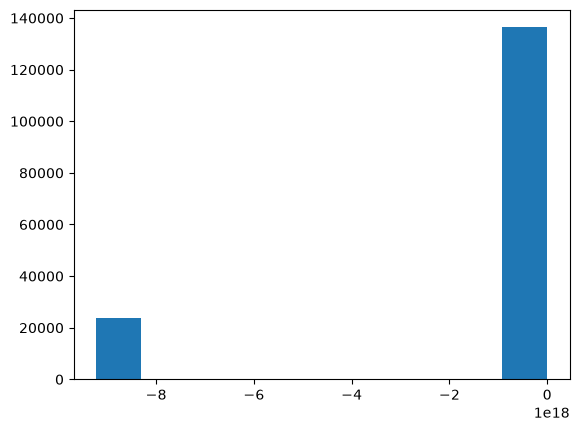

In [202]:
plt.hist(np.ravel(ds.BLOOM_INITIATION_TS_DATE_CHLA))

In [196]:
np.ravel(ds.BLOOM_INITIATION_TS_DATE_CHLA)[0].to_datetime()

AttributeError: 'numpy.int64' object has no attribute 'to_datetime'